In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from scipy import stats
import warnings

In [ ]:
import pandas as pd
import numpy as np
import csv
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

In [ ]:
try:
    df = pd.read_csv("final_data2.csv",
                    sep=',',
                    on_bad_lines='skip',
                    engine='c',
                    quoting=csv.QUOTE_MINIMAL)
    print(f"Veri seti yüklendi. Satır sayısı: {len(df)}")
except:
    df = pd.read_csv("final_data2.csv", on_bad_lines='skip', engine='python')

Veri seti yüklendi. Satır sayısı: 20405


/tmp/ipython-input-177114470.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='sentiment', data=df, ax=axes[0, 0], palette=custom_palette, showfliers=False)
/tmp/ipython-input-177114470.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0, 0].set_xticklabels(['Real News', 'Fake News'])
/tmp/ipython-input-177114470.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='subjectivity', data=df, ax=axes[0, 1], palette=custom_palette, showfliers=False)
/tmp/ipython-input-177114470.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

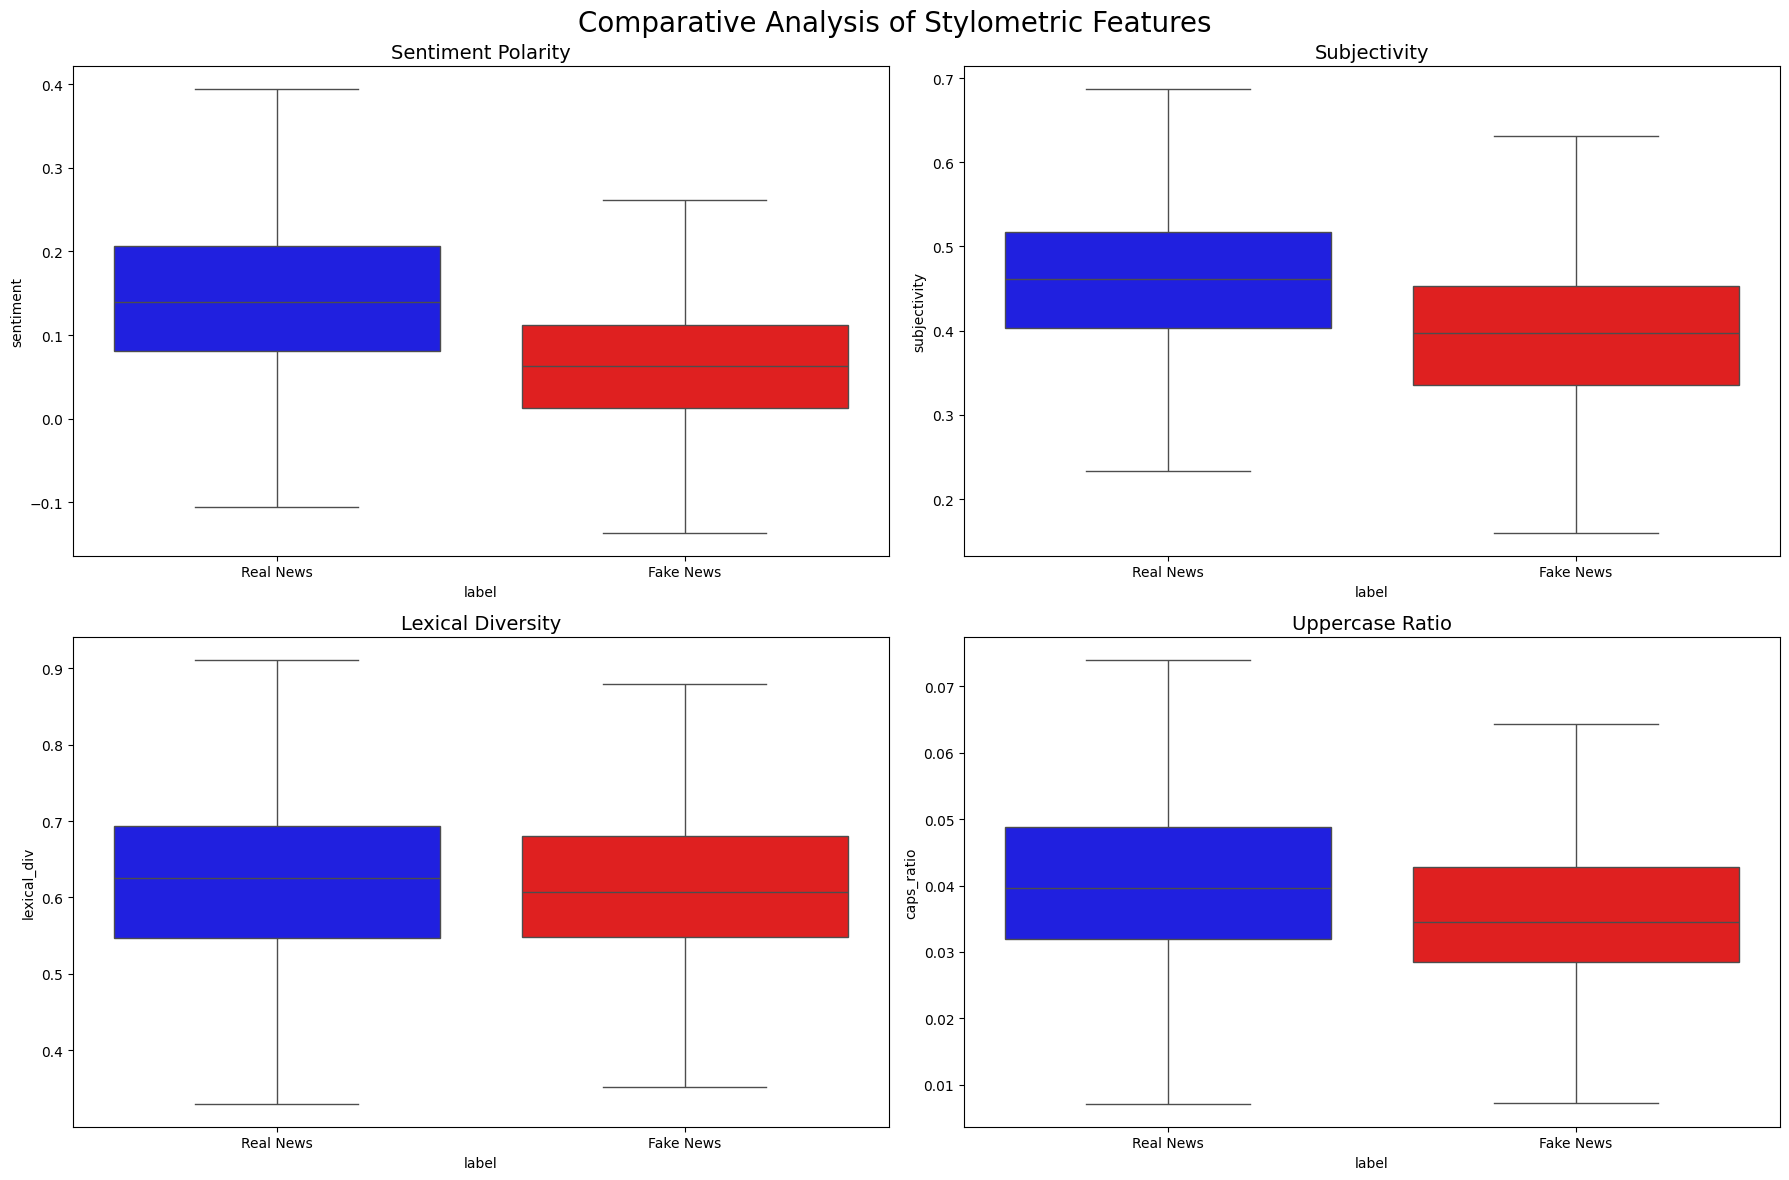

In [ ]:
 # BOX PLOTS

df['label'] = df['label'].astype(str)
custom_palette = {'0': 'blue', '1': 'red'}
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# sentiment plot
sns.boxplot(x='label', y='sentiment', data=df, ax=axes[0, 0], palette=custom_palette, showfliers=False)
axes[0, 0].set_title('Sentiment Polarity', fontsize=14)
axes[0, 0].set_xticklabels(['Real News', 'Fake News'])

# Subjectivity plot
sns.boxplot(x='label', y='subjectivity', data=df, ax=axes[0, 1], palette=custom_palette, showfliers=False)
axes[0, 1].set_title('Subjectivity', fontsize=14)
axes[0, 1].set_xticklabels(['Real News', 'Fake News'])

# Lexical diversity
sns.boxplot(x='label', y='lexical_div', data=df, ax=axes[1, 0], palette=custom_palette, showfliers=False)
axes[1, 0].set_title('Lexical Diversity', fontsize=14)
axes[1, 0].set_xticklabels(['Real News', 'Fake News'])

# Caps Ratio
sns.boxplot(x='label', y='caps_ratio', data=df, ax=axes[1, 1], palette=custom_palette, showfliers=False)
axes[1, 1].set_title('Uppercase Ratio', fontsize=14)
axes[1, 1].set_xticklabels(['Real News', 'Fake News'])

plt.suptitle('Comparative Analysis of Stylometric Features', fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

features_6 = ['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']

# df_temp oluşturarak ana verini bozmadan sadece bu grafik için temizlik yapıyoruz
df_clean = df.dropna(subset=features_6 + ['label'])

X_6 = df_clean[features_6]
y_6 = df_clean['label'].astype(int)
scaler = MinMaxScaler()
X_scaled_6 = scaler.fit_transform(X_6)

pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(X_scaled_6)
pca_df = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
pca_df['label'] = y_6.values

# overplotting'i önlemek için karıştırıyoruz
pca_df = pca_df.sample(frac=1, random_state=42).reset_index(drop=True)

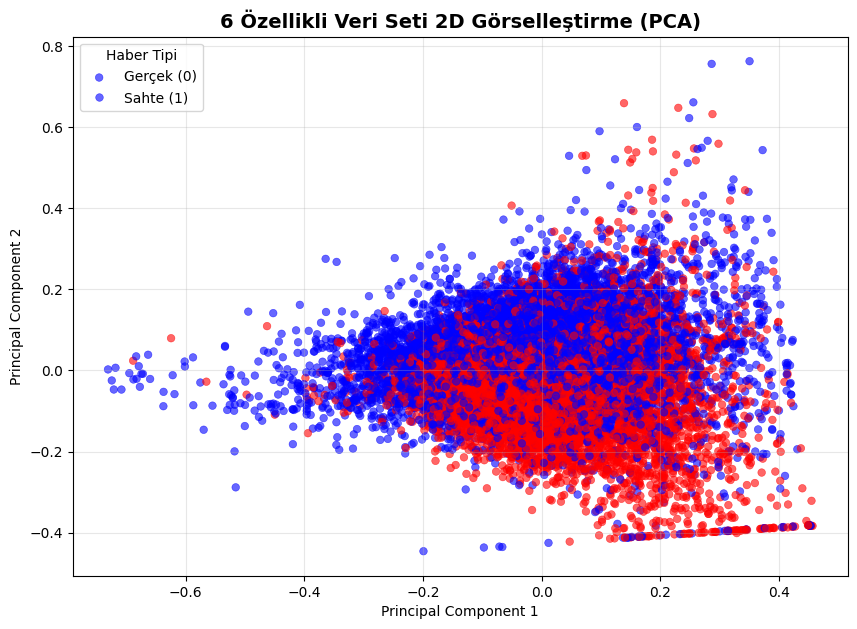

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='label', data=pca_df,
                palette={0: 'blue', 1: 'red'}, alpha=0.6, s=30, edgecolor=None)

plt.title('6 Özellikli Veri Seti 2D Görselleştirme (PCA)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Haber Tipi', labels=['Gerçek (0)', 'Sahte (1)'])
plt.grid(alpha=0.3)
plt.show()

Bu dağılım grafiği elimizdeki 6 özelliğin bilgilerini 2 boyuta sıkıştırılmış halidir.

Bu görsele baktığımızda, yalan ve gerçek haberlerin artık birbirine yakın sayıda olduğunu ve benzer bölgelerde yoğunlaştığını görebiliyoruz.

Bu iç içe geçmelerden anlayabileceğimiz üzere,yalan haberler gerçek haberlere benzemesi için profesyonelce yazılarak gerçek haberleri taklit ediyorlar.

Çok iç içe olmaları doğrusal bir sınır çizemeyeceğimiz yani linear modellerin lineer olmayan modellerden daha düşük başarı oranını sağlayacağı ipucunu veriyor.

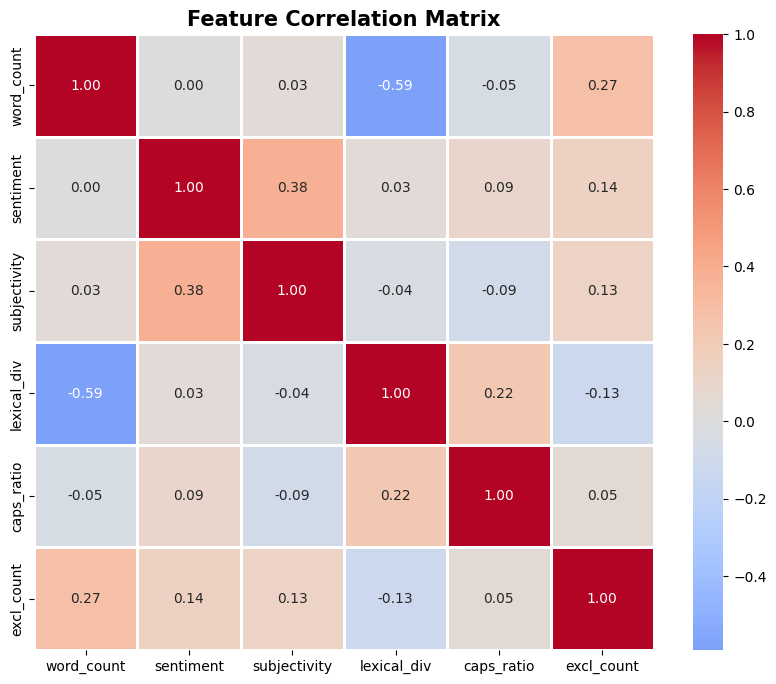

In [ ]:
# Correlation Matrix
import seaborn as sns
import matplotlib.pyplot as plt
df['label_num'] = df['label'].astype(int)


corr_feats = ['word_count', 'sentiment', 'subjectivity', 'lexical_div', 'caps_ratio', 'excl_count']
corr_matrix = df[corr_feats].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.show()

Korelasyonlar eskisiyle aynı sayılır, değişemezdi zaten sanırım

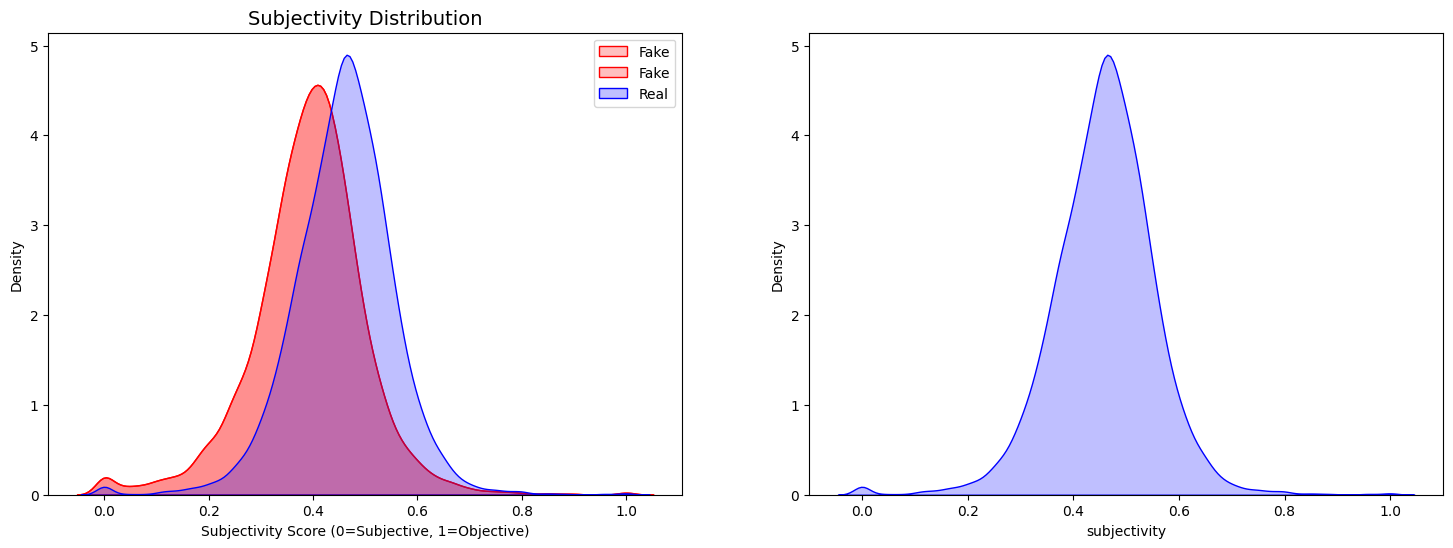

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.kdeplot(df[df['label']=='1']['subjectivity'], fill=True, color='red', label='Fake', ax=axes[0])
sns.kdeplot(df[df['label']=='0']['subjectivity'], fill=True, color='blue', label='Real', ax=axes[1])

sns.kdeplot(df[df['label']=='1']['subjectivity'], fill=True, color='red', label='Fake', ax=axes[0])
sns.kdeplot(df[df['label']=='0']['subjectivity'], fill=True, color='blue', label='Real', ax=axes[0])

axes[0].set_title('Subjectivity Distribution', fontsize=14)
axes[0].set_xlabel('Subjectivity Score (0=Subjective, 1=Objective)')
axes[0].legend()

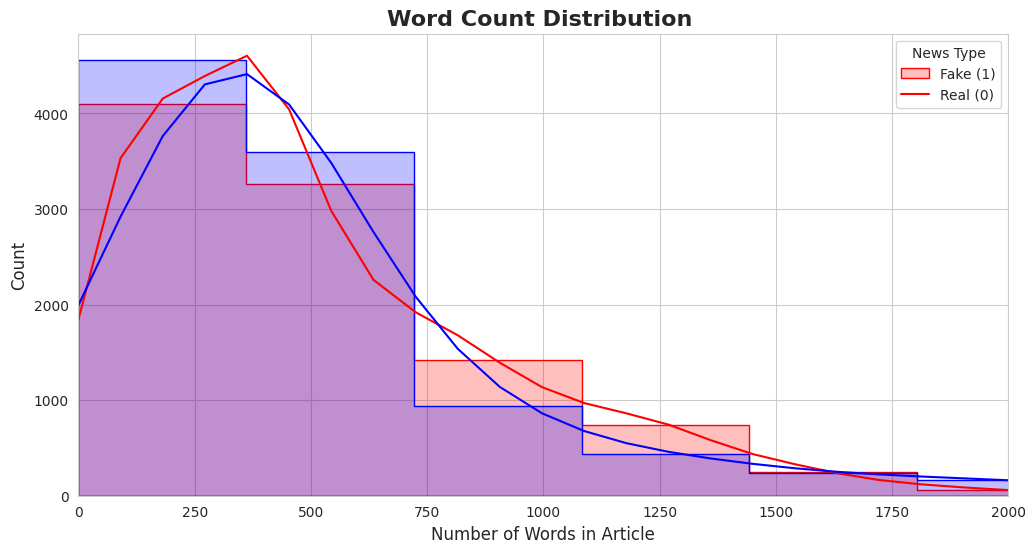


 Statistics of Word Count


         count        mean          std  min    25%    50%    75%      max
label                                                                     
0      10456.0  708.717961  1270.805638  0.0  250.0  404.0  652.0  18036.0
1       9949.0  556.281938   568.778253  1.0  227.0  410.0  739.0  14641.0


In [ ]:
df['label'] = df['label'].astype(int)
if 'word_count' not in df.columns:
  target_col = 'full_text' if 'full_text' in df.columns else 'clean_title'
  df['word_count'] = df[target_col].fillna('').astype(str).apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

sns.histplot(data=df, x='word_count', hue='label', kde=True, element="step",
             palette={0:'blue', 1:'red'}, bins=50)

plt.title('Word Count Distribution ', fontsize=16, fontweight='bold')
plt.xlabel('Number of Words in Article', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.xlim(0, 2000) # x axis limit for graph

plt.legend(title='News Type', labels=['Fake (1)', 'Real (0)'])
plt.show()

  # printing statistics
print("\n Statistics of Word Count")
print("\n")
print(df.groupby('label')['word_count'].describe())

False haber sayısını arttırdığımız için doğal olarak kırmızı grafik yukarıya çıktı,ve belli bir kısımdan sonra gerçek haberlerden daha fazla oluyor.

GENEL OLARAK NOTEBOOK UN ÖZETİ:

Dağılım Analizi (Box Plots): Özelliklerin sınıflara göre dağılımı kutu grafikleriyle gösterilerek uç değerler ve medyan farkları incelenir.

İlişki Analizi (Scatter Plots): Örneğin kelime sayısı ile kelime çeşitliliği arasındaki ilişki görselleştirilerek veri setinin karakteristik yapısı ortaya konur.

Özet: Verilerin modeller tarafından öğrenilmeye uygun olduğu bilimsel olarak kanıtlanır.